# 🛡️ Adversarial Attack & Robustness in CNNs
### CIFAR-10 | FGSM · PGD · Adversarial Training
---
**Run order:** Execute cells top-to-bottom.

| Step | Description |
|------|-------------|
| 0 | Setup & GPU check |
| 1 | CNN architecture + data |
| 2 | Train clean CNN (~10 min) |
| 3 | FGSM attack |
| 4 | PGD attack |
| 5 | Robustness evaluation |
| 6 | Adversarial training defense (~20 min) |
| 7 | Final comparison |

## Step 0 — Setup & GPU Check

In [ ]:
import torch, torchvision, os, numpy as np
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('No GPU — go to Runtime > Change runtime type > T4 GPU')

os.makedirs('checkpoints', exist_ok=True)
print('All imports OK')

## Step 1 — Model Architecture & Data Loaders

In [10]:
CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
CIFAR_STD  = torch.tensor([0.2470, 0.2435, 0.2616])

def get_loaders(batch_size=128):
    mean, std = CIFAR_MEAN.tolist(), CIFAR_STD.tolist()
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_set = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
    test_set  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

train_loader, test_loader = get_loaders()
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
    return 100. * correct / total

def clamp_valid(x):
    lo = ((0. - CIFAR_MEAN) / CIFAR_STD).to(DEVICE).view(1,3,1,1)
    hi = ((1. - CIFAR_MEAN) / CIFAR_STD).to(DEVICE).view(1,3,1,1)
    return torch.clamp(x, lo, hi)

def denorm(t):
    return torch.clamp(t.cpu() * CIFAR_STD.view(3,1,1) + CIFAR_MEAN.view(3,1,1), 0, 1)

model = SimpleCNN().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print('Model ready')

Train batches: 391 | Test batches: 79
Parameters: 3,249,994
Model ready


## Step 2 — Train Clean CNN
> ~8-12 min on T4 GPU for 30 epochs

 Epoch      Loss    Train%     Test%
--------------------------------------
     1    2.2630    14.49%    21.96% saved
     2    1.9845    22.79%    31.03% saved
     3    1.7438    34.20%    46.43% saved
     4    1.5394    43.24%    55.85% saved
     5    1.3681    50.74%    59.10% saved
     6    1.2468    56.11%    61.91% saved
     7    1.1374    59.99%    69.18% saved
     8    1.0614    63.31%    68.67%
     9    0.9863    66.20%    68.23%
    10    0.9327    68.27%    69.54% saved
    11    0.8813    70.34%    75.64% saved
    12    0.8404    71.40%    78.77% saved
    13    0.8034    73.02%    80.85% saved
    14    0.7666    74.31%    80.76%
    15    0.7259    75.59%    78.82%
    16    0.7036    76.73%    79.38%
    17    0.6769    77.53%    83.15% saved
    18    0.6420    78.62%    81.60%
    19    0.6105    79.70%    83.52% saved
    20    0.5854    80.52%    84.61% saved
    21    0.5526    81.72%    86.11% saved
    22    0.5228    82.65%    84.40%
    23    0.5020    

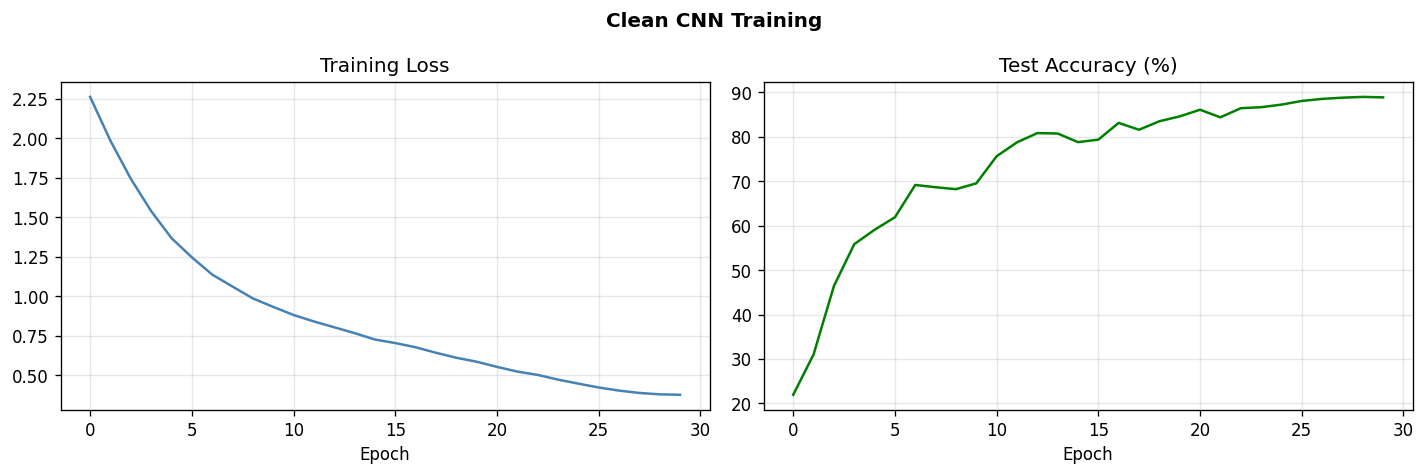

In [3]:
EPOCHS = 30
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_acc = 0.0
train_losses, test_accs = [], []

print(f'{"Epoch":>6}  {"Loss":>8}  {"Train%":>8}  {"Test%":>8}')
print('-' * 38)

for epoch in range(1, EPOCHS+1):
    model.train()
    loss_sum = correct = total = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * lbls.size(0)
        correct  += (out.argmax(1) == lbls).sum().item()
        total    += lbls.size(0)
    scheduler.step()
    tl  = loss_sum / total
    tra = 100. * correct / total
    tea = evaluate(model, test_loader)
    train_losses.append(tl)
    test_accs.append(tea)
    marker = ''
    if tea > best_acc:
        best_acc = tea
        torch.save(model.state_dict(), 'checkpoints/cnn_clean.pth')
        marker = ' saved'
    print(f'{epoch:>6}  {tl:>8.4f}  {tra:>7.2f}%  {tea:>7.2f}%{marker}')

print(f'Best test accuracy: {best_acc:.2f}%')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(train_losses, color='steelblue')
a1.set_title('Training Loss'); a1.set_xlabel('Epoch'); a1.grid(alpha=0.3)
a2.plot(test_accs, color='green')
a2.set_title('Test Accuracy (%)'); a2.set_xlabel('Epoch'); a2.grid(alpha=0.3)
plt.suptitle('Clean CNN Training', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3 — FGSM Attack
**Theory:** `x_adv = x + eps * sign(grad_x L)`  
One gradient step in the direction that maximises the loss.

   Epsilon    Accuracy
------------------------
     0.000      89.00%
     0.010      71.80%
     0.020      53.15%
     0.030      39.73%
     0.050      22.74%
     0.100       9.68%
     0.200       7.96%
     0.300       9.85%


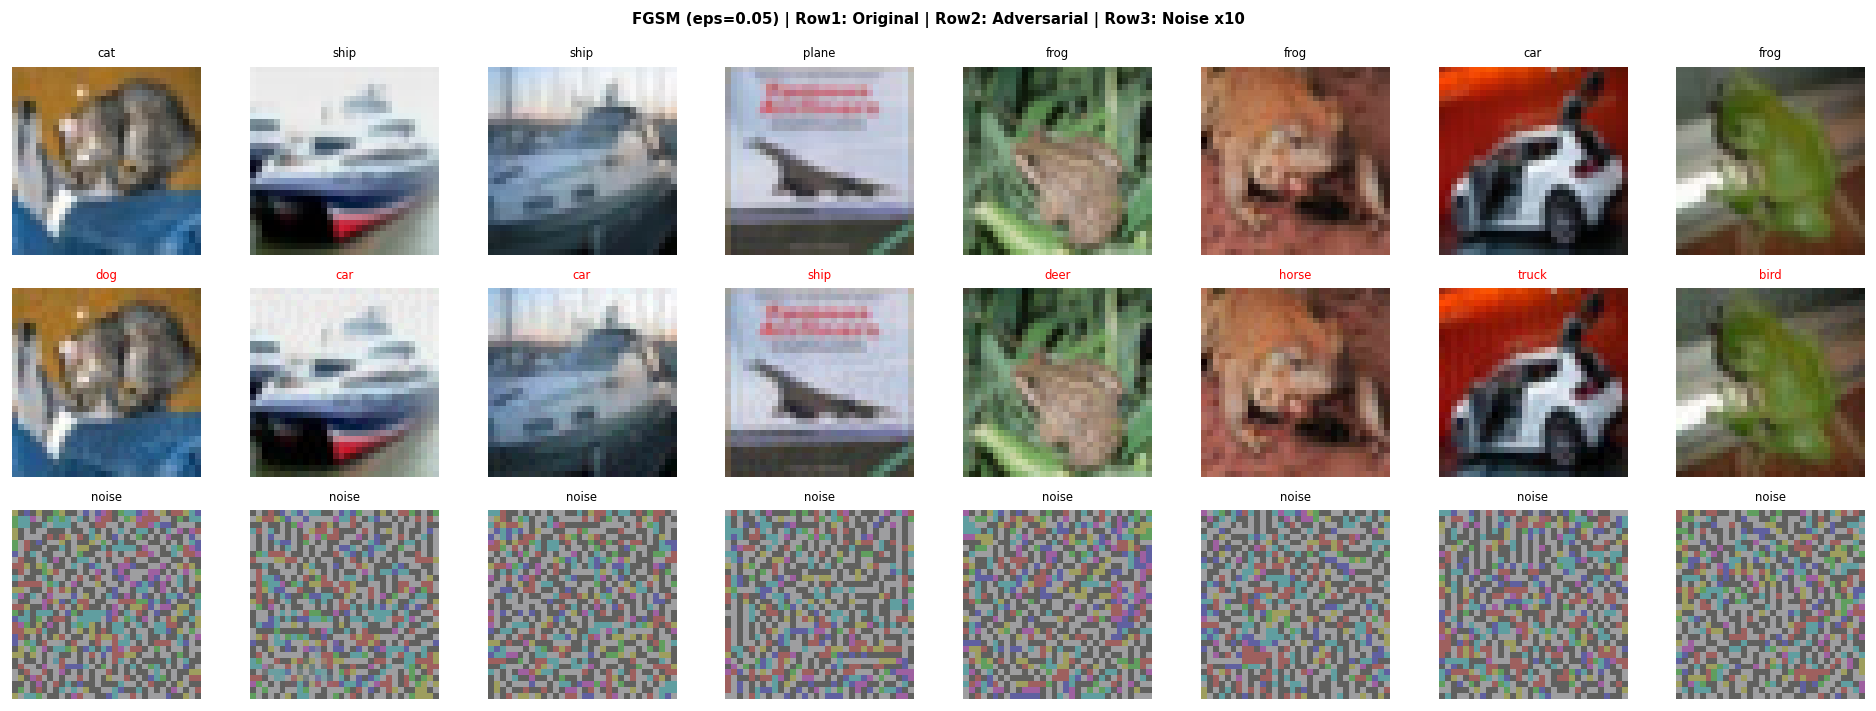

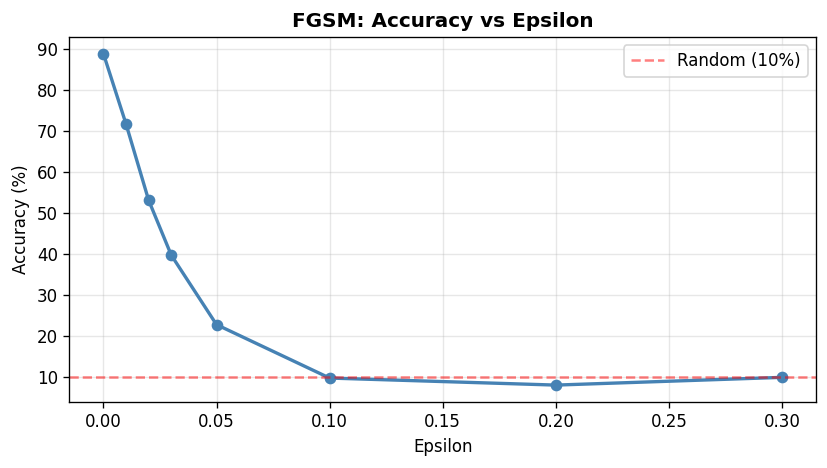

In [4]:
model.load_state_dict(torch.load('checkpoints/cnn_clean.pth', map_location=DEVICE))
model.eval()

def fgsm(images, labels, eps):
    x = images.clone().detach().requires_grad_(True)
    criterion(model(x), labels).backward()
    return clamp_valid(images + eps * x.grad.sign()).detach()

epsilons = [0.0, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3]
fgsm_accs = []
print(f'{"Epsilon":>10}  {"Accuracy":>10}')
print('-' * 24)
for eps in epsilons:
    correct = total = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        adv = fgsm(imgs, lbls, eps) if eps > 0 else imgs
        correct += (model(adv).argmax(1) == lbls).sum().item()
        total   += lbls.size(0)
    acc = 100.*correct/total
    fgsm_accs.append(acc)
    print(f'{eps:>10.3f}  {acc:>9.2f}%')

# Visualise examples
EPS_VIS = 0.05
imgs_v, lbls_v = next(iter(test_loader))
imgs_v, lbls_v = imgs_v[:8].to(DEVICE), lbls_v[:8].to(DEVICE)
adv_v = fgsm(imgs_v, lbls_v, EPS_VIS)
cp = model(imgs_v).argmax(1).cpu()
ap = model(adv_v).argmax(1).cpu()
lc = lbls_v.cpu()

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle(f'FGSM (eps={EPS_VIS}) | Row1: Original | Row2: Adversarial | Row3: Noise x10',
             fontsize=9, fontweight='bold')
for i in range(8):
    orig = denorm(imgs_v[i]).permute(1,2,0).numpy()
    adv  = denorm(adv_v[i]).permute(1,2,0).numpy()
    diff = np.clip((adv - orig)*10 + 0.5, 0, 1)
    axes[0,i].imshow(orig);  axes[0,i].set_title(f'{CLASSES[lc[i]]}', fontsize=7);  axes[0,i].axis('off')
    color = 'red' if ap[i] != lc[i] else 'green'
    axes[1,i].imshow(adv);   axes[1,i].set_title(f'{CLASSES[ap[i]]}', fontsize=7, color=color); axes[1,i].axis('off')
    axes[2,i].imshow(diff);  axes[2,i].set_title('noise', fontsize=7); axes[2,i].axis('off')
plt.tight_layout()
plt.show()

# Accuracy curve
fig2, ax = plt.subplots(figsize=(7,4))
ax.plot(epsilons, fgsm_accs, 'o-', color='steelblue', linewidth=2)
ax.axhline(10, color='red', linestyle='--', alpha=0.5, label='Random (10%)')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.set_title('FGSM: Accuracy vs Epsilon', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — PGD Attack
**Theory:** Multi-step attack constrained to epsilon-ball  
`x_{t+1} = Project_{B(x,eps)}[ x_t + alpha * sign(grad L) ]`

Clean accuracy: 89.00%
   Steps     PGD Acc
----------------------
       1      76.96%
       5      33.14%
      10      20.65%
      20      17.79%
      40      17.07%


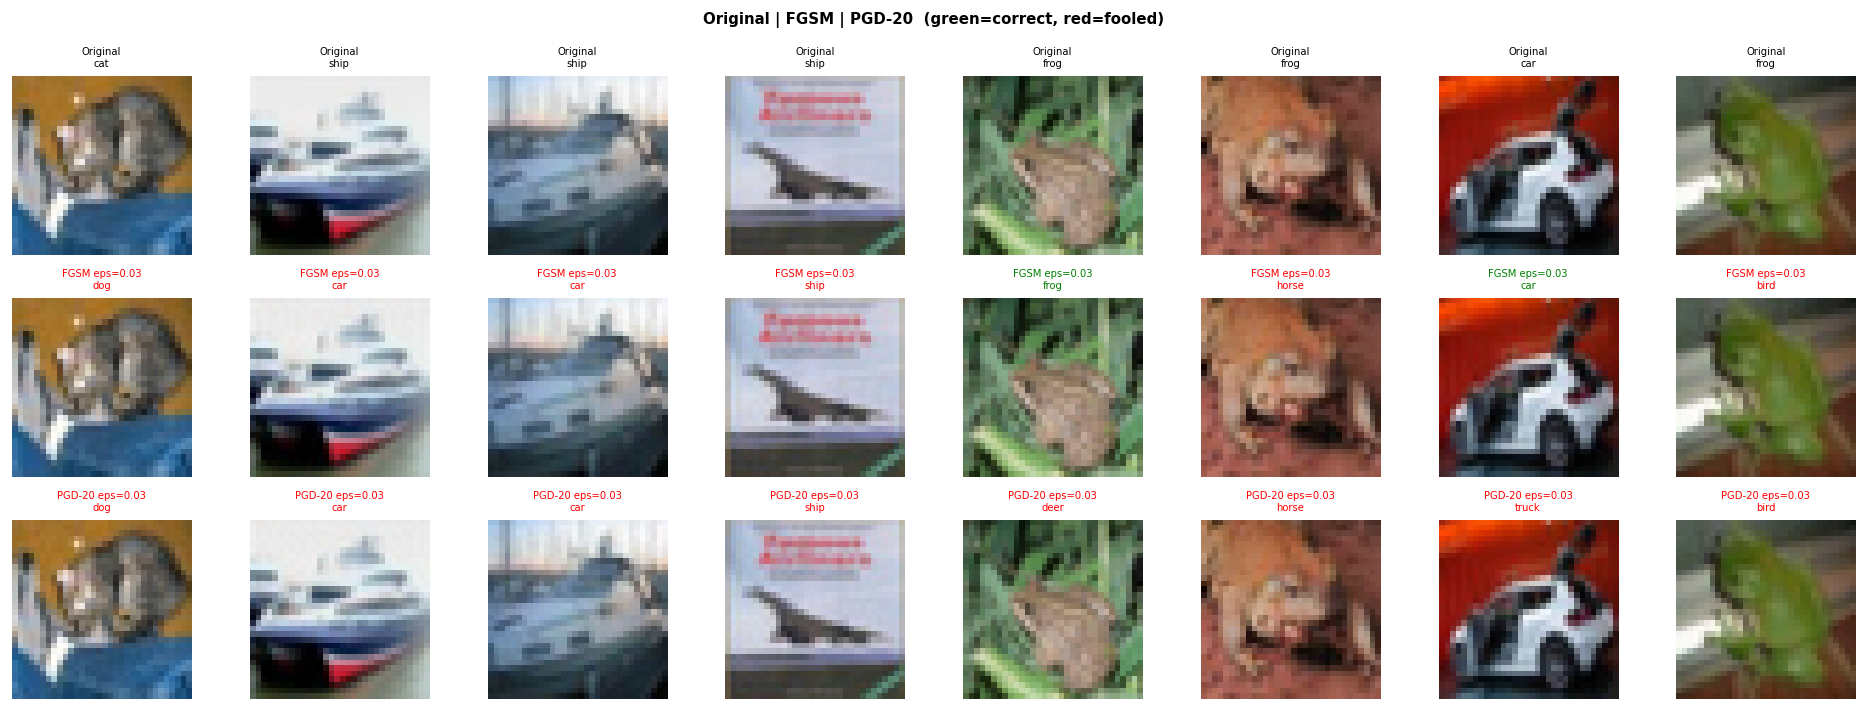

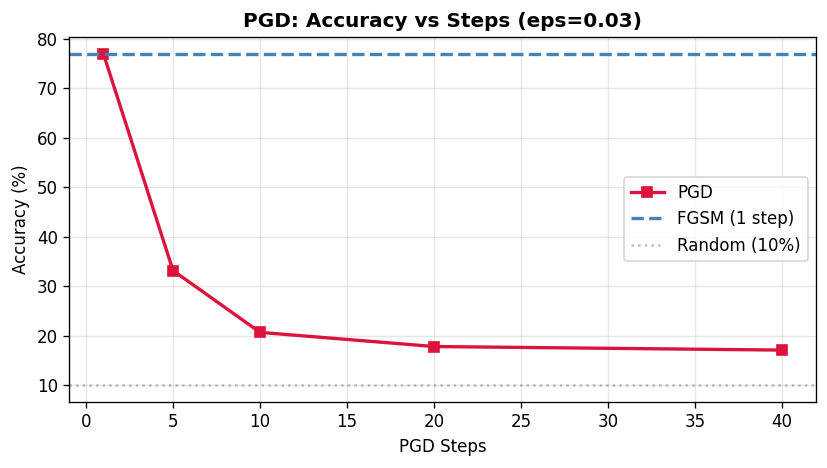

In [5]:
def pgd(images, labels, eps, alpha=None, steps=20):
    if alpha is None:
        alpha = eps / 4
    x_orig = images.clone().detach()
    x = clamp_valid(x_orig + torch.empty_like(images).uniform_(-eps, eps))
    for _ in range(steps):
        x.requires_grad_(True)
        criterion(model(x), labels).backward()
        with torch.no_grad():
            x = clamp_valid(x_orig + torch.clamp(x + alpha*x.grad.sign() - x_orig, -eps, eps))
    return x.detach()

EPS = 0.03
step_counts = [1, 5, 10, 20, 40]
step_accs   = []
print(f'Clean accuracy: {evaluate(model, test_loader):.2f}%')
print(f'{"Steps":>8}  {"PGD Acc":>10}')
print('-' * 22)
for s in step_counts:
    correct = total = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        adv = pgd(imgs, lbls, EPS, steps=s)
        correct += (model(adv).argmax(1) == lbls).sum().item()
        total   += lbls.size(0)
    acc = 100.*correct/total
    step_accs.append(acc)
    print(f'{s:>8}  {acc:>9.2f}%')

# Visualise side-by-side
imgs_v2, lbls_v2 = next(iter(test_loader))
imgs_v2, lbls_v2 = imgs_v2[:8].to(DEVICE), lbls_v2[:8].to(DEVICE)
fgsm_v2 = fgsm(imgs_v2, lbls_v2, EPS)
pgd_v2  = pgd(imgs_v2,  lbls_v2, EPS, steps=20)
rows       = [imgs_v2, fgsm_v2, pgd_v2]
row_labels = ['Original', f'FGSM eps={EPS}', f'PGD-20 eps={EPS}']
preds_rows = [model(r).argmax(1).cpu() for r in rows]
lc2 = lbls_v2.cpu()

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Original | FGSM | PGD-20  (green=correct, red=fooled)', fontsize=9, fontweight='bold')
for r, (row_imgs, row_preds, rlabel) in enumerate(zip(rows, preds_rows, row_labels)):
    for c in range(8):
        img = denorm(row_imgs[c]).permute(1,2,0).numpy()
        color = 'black' if r == 0 else ('green' if row_preds[c]==lc2[c] else 'red')
        axes[r,c].imshow(img)
        axes[r,c].set_title(f'{rlabel}\n{CLASSES[row_preds[c]]}', fontsize=6, color=color)
        axes[r,c].axis('off')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7,4))
ax2.plot(step_counts, step_accs, 's-', color='crimson', linewidth=2, label='PGD')
ax2.axhline(step_accs[0], color='steelblue', linestyle='--', linewidth=2, label='FGSM (1 step)')
ax2.axhline(10, color='grey', linestyle=':', alpha=0.5, label='Random (10%)')
ax2.set_xlabel('PGD Steps'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title(f'PGD: Accuracy vs Steps (eps={EPS})', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5 — Robustness Evaluation Suite

Sweeping FGSM ...
  eps=0.000  89.00%
  eps=0.010  71.80%
  eps=0.020  53.15%
  eps=0.030  39.73%
  eps=0.050  22.74%
  eps=0.075  13.44%
  eps=0.100  9.68%
  eps=0.150  7.61%
  eps=0.200  7.96%
  eps=0.300  9.85%
Sweeping PGD-20 ...
  eps=0.000  89.00%
  eps=0.010  67.25%
  eps=0.020  39.13%
  eps=0.030  17.86%
  eps=0.050  2.19%
  eps=0.075  0.34%
  eps=0.100  0.15%
  eps=0.150  0.03%
  eps=0.200  0.00%
  eps=0.300  0.00%


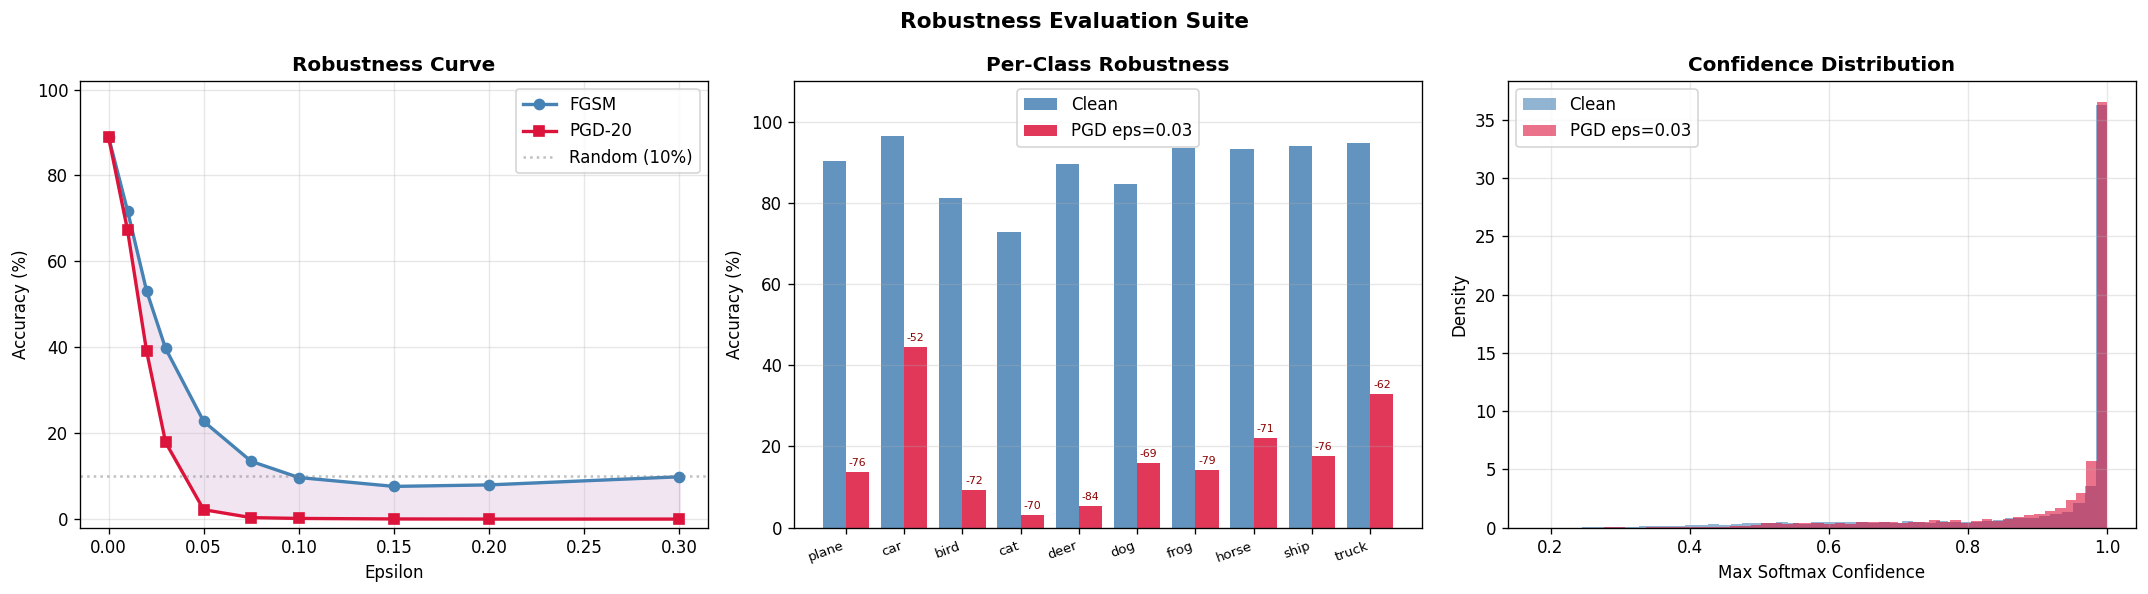

Mean clean confidence: 0.9071
Mean adv   confidence: 0.9245


In [6]:
epsilons_sweep = [0.0, 0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3]
fgsm_sweep, pgd_sweep = [], []

print('Sweeping FGSM ...')
for eps in epsilons_sweep:
    correct = total = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        adv = fgsm(imgs, lbls, eps) if eps > 0 else imgs
        correct += (model(adv).argmax(1) == lbls).sum().item()
        total   += lbls.size(0)
    fgsm_sweep.append(100.*correct/total)
    print(f'  eps={eps:.3f}  {fgsm_sweep[-1]:.2f}%')

print('Sweeping PGD-20 ...')
for eps in epsilons_sweep:
    correct = total = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        adv = pgd(imgs, lbls, eps, steps=20) if eps > 0 else imgs
        correct += (model(adv).argmax(1) == lbls).sum().item()
        total   += lbls.size(0)
    pgd_sweep.append(100.*correct/total)
    print(f'  eps={eps:.3f}  {pgd_sweep[-1]:.2f}%')

# Per-class robustness
EPS_EVAL = 0.03
clean_pc = [0]*10; pgd_pc = [0]*10; total_pc = [0]*10
for imgs, lbls in test_loader:
    imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
    adv = pgd(imgs, lbls, EPS_EVAL)
    cp2 = model(imgs).argmax(1)
    ap2 = model(adv).argmax(1)
    for c in range(10):
        mask = (lbls == c)
        total_pc[c] += mask.sum().item()
        clean_pc[c] += (cp2[mask] == c).sum().item()
        pgd_pc[c]   += (ap2[mask] == c).sum().item()
clean_cls = [100.*clean_pc[c]/total_pc[c] for c in range(10)]
pgd_cls   = [100.*pgd_pc[c]/total_pc[c]   for c in range(10)]

# Confidence histogram
clean_conf, adv_conf = [], []
for imgs, lbls in test_loader:
    imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
    adv = pgd(imgs, lbls, EPS_EVAL)
    with torch.no_grad():
        clean_conf.extend(F.softmax(model(imgs),1).max(1).values.cpu().numpy())
        adv_conf.extend(  F.softmax(model(adv), 1).max(1).values.cpu().numpy())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(epsilons_sweep, fgsm_sweep, 'o-', color='steelblue', linewidth=2, label='FGSM')
ax.plot(epsilons_sweep, pgd_sweep,  's-', color='crimson',   linewidth=2, label='PGD-20')
ax.fill_between(epsilons_sweep, fgsm_sweep, pgd_sweep, alpha=0.1, color='purple')
ax.axhline(10, color='grey', linestyle=':', alpha=0.5, label='Random (10%)')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Robustness Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-2, 102)

ax2 = axes[1]
xc = np.arange(10)
b1 = ax2.bar(xc-0.2, clean_cls, 0.4, label='Clean',              color='steelblue', alpha=0.85)
b2 = ax2.bar(xc+0.2, pgd_cls,   0.4, label=f'PGD eps={EPS_EVAL}', color='crimson',   alpha=0.85)
ax2.set_xticks(xc); ax2.set_xticklabels(CLASSES, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Per-Class Robustness', fontweight='bold')
ax2.legend(); ax2.grid(axis='y', alpha=0.3); ax2.set_ylim(0, 110)
for bb1, bb2 in zip(b1, b2):
    drop = bb1.get_height() - bb2.get_height()
    ax2.text(bb2.get_x()+bb2.get_width()/2, bb2.get_height()+1,
             f'-{drop:.0f}', ha='center', va='bottom', fontsize=6.5, color='darkred')

ax3 = axes[2]
ax3.hist(clean_conf, bins=50, alpha=0.6, color='steelblue', label='Clean',              density=True)
ax3.hist(adv_conf,   bins=50, alpha=0.6, color='crimson',   label=f'PGD eps={EPS_EVAL}', density=True)
ax3.set_xlabel('Max Softmax Confidence'); ax3.set_ylabel('Density')
ax3.set_title('Confidence Distribution', fontweight='bold')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('Robustness Evaluation Suite', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Mean clean confidence: {np.mean(clean_conf):.4f}')
print(f'Mean adv   confidence: {np.mean(adv_conf):.4f}')

## Step 6 — Adversarial Training (Defense)
**Theory:** Train on worst-case examples each batch  
> ~15-20 min on T4 GPU for 25 epochs

In [7]:
ADV_EPS    = 0.03
ADV_ALPHA  = 0.007
ADV_STEPS  = 7
ADV_EPOCHS = 25

robust_model = SimpleCNN().to(DEVICE)
opt_r   = optim.SGD(robust_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4, nesterov=True)
sched_r = CosineAnnealingLR(opt_r, T_max=ADV_EPOCHS)

def pgd_train(mdl, images, labels, eps, alpha, steps):
    x = clamp_valid(images + torch.empty_like(images).uniform_(-eps, eps))
    for _ in range(steps):
        x.requires_grad_(True)
        criterion(mdl(x), labels).backward()
        with torch.no_grad():
            x = clamp_valid(images + torch.clamp(x + alpha*x.grad.sign() - images, -eps, eps))
    return x.detach()

r_hist = {'clean': [], 'adv': []}
best_robust = 0.0

print(f'{"Epoch":>6}  {"Loss":>8}  {"Clean%":>8}  {"Adv%":>8}')
print('-' * 38)

for epoch in range(1, ADV_EPOCHS+1):
    loss_sum = n = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        robust_model.eval()
        adv_imgs = pgd_train(robust_model, imgs, lbls, ADV_EPS, ADV_ALPHA, ADV_STEPS)
        robust_model.train()
        opt_r.zero_grad()
        loss = criterion(robust_model(adv_imgs), lbls)
        loss.backward()
        opt_r.step()
        loss_sum += loss.item() * lbls.size(0)
        n        += lbls.size(0)
    sched_r.step()
    robust_model.eval()
    ca = evaluate(robust_model, test_loader)
    correct = total = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        adv = pgd_train(robust_model, imgs, lbls, ADV_EPS, ADV_EPS/4, 20)
        correct += (robust_model(adv).argmax(1) == lbls).sum().item()
        total   += lbls.size(0)
    aa = 100.*correct/total
    r_hist['clean'].append(ca)
    r_hist['adv'].append(aa)
    marker = ''
    if aa > best_robust:
        best_robust = aa
        torch.save(robust_model.state_dict(), 'checkpoints/cnn_robust.pth')
        marker = ' saved'
    print(f'{epoch:>6}  {loss_sum/n:>8.4f}  {ca:>7.2f}%  {aa:>7.2f}%{marker}')

print(f'Best robust adv accuracy: {best_robust:.2f}%')

 Epoch      Loss    Clean%      Adv%
--------------------------------------
     1    1.8807    47.43%    40.31% saved
     2    1.7052    52.16%    43.58% saved
     3    1.6069    55.63%    46.57% saved
     4    1.5282    58.99%    49.23% saved
     5    1.4679    61.46%    50.71% saved
     6    1.4065    66.04%    54.74% saved
     7    1.3549    67.29%    55.92% saved
     8    1.3138    68.04%    56.55% saved
     9    1.2711    70.05%    57.83% saved
    10    1.2329    69.64%    57.64%
    11    1.2019    73.39%    60.81% saved
    12    1.1748    74.12%    61.26% saved
    13    1.1441    74.18%    61.55% saved
    14    1.1170    75.03%    62.93% saved
    15    1.0922    76.20%    63.68% saved
    16    1.0708    75.85%    63.42%
    17    1.0469    77.22%    63.92% saved
    18    1.0334    77.53%    64.49% saved
    19    1.0111    78.17%    65.34% saved
    20    1.0010    78.33%    64.92%
    21    0.9888    78.96%    65.91% saved
    22    0.9783    79.61%    66.09% sa

## Step 7 — Final Comparison: Standard vs Adversarially Trained

     eps      Standard   Adv-Trained      Gain
----------------------------------------------
   0.000        89.00%        79.52%    -9.48%
   0.010        67.24%        75.52%    +8.28%
   0.020        39.13%        71.18%   +32.05%
   0.030        17.86%        66.30%   +48.44%
   0.050         2.26%        55.59%   +53.33%
   0.075         0.32%        40.98%   +40.66%
   0.100         0.15%        28.51%   +28.36%


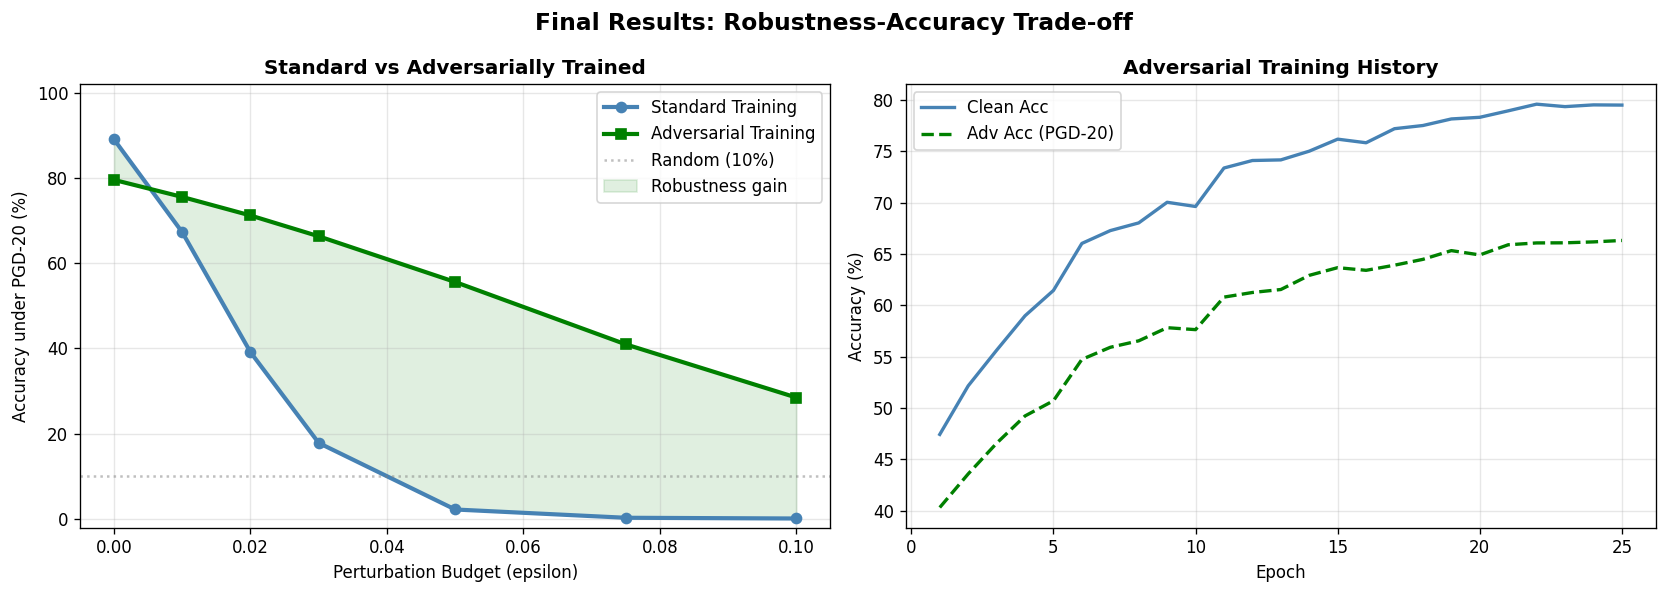

Model                   Clean   PGD-20 eps=0.03
Standard                89.0%             17.9%
Adv. Trained            79.5%             66.3%


In [8]:
clean_m  = SimpleCNN().to(DEVICE)
clean_m.load_state_dict(torch.load('checkpoints/cnn_clean.pth',  map_location=DEVICE))
clean_m.eval()

robust_m = SimpleCNN().to(DEVICE)
robust_m.load_state_dict(torch.load('checkpoints/cnn_robust.pth', map_location=DEVICE))
robust_m.eval()

eps_final = [0.0, 0.01, 0.02, 0.03, 0.05, 0.075, 0.1]
clean_final, robust_final = [], []

def eval_pgd_mdl(mdl, eps):
    correct = total = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        adv = pgd_train(mdl, imgs, lbls, eps, eps/4, 20) if eps > 0 else imgs
        correct += (mdl(adv).argmax(1) == lbls).sum().item()
        total   += lbls.size(0)
    return 100.*correct/total

print(f'{"eps":>8}  {"Standard":>12}  {"Adv-Trained":>12}  {"Gain":>8}')
print('-' * 46)
for eps in eps_final:
    ca = eval_pgd_mdl(clean_m,  eps)
    ra = eval_pgd_mdl(robust_m, eps)
    clean_final.append(ca)
    robust_final.append(ra)
    print(f'{eps:>8.3f}  {ca:>11.2f}%  {ra:>11.2f}%  {ra-ca:>+7.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(eps_final, clean_final,  'o-', color='steelblue', linewidth=2.5, label='Standard Training')
ax.plot(eps_final, robust_final, 's-', color='green',     linewidth=2.5, label='Adversarial Training')
ax.axhline(10, color='grey', linestyle=':', alpha=0.5, label='Random (10%)')
ax.fill_between(eps_final, clean_final, robust_final, alpha=0.12, color='green', label='Robustness gain')
ax.set_xlabel('Perturbation Budget (epsilon)')
ax.set_ylabel('Accuracy under PGD-20 (%)')
ax.set_title('Standard vs Adversarially Trained', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-2, 102)

ax2 = axes[1]
epochs_r = list(range(1, len(r_hist['clean'])+1))
ax2.plot(epochs_r, r_hist['clean'], '-',  color='steelblue', linewidth=2, label='Clean Acc')
ax2.plot(epochs_r, r_hist['adv'],   '--', color='green',     linewidth=2, label='Adv Acc (PGD-20)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Adversarial Training History', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Final Results: Robustness-Accuracy Trade-off', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 52)
print(f'{"Model":<20} {"Clean":>8}  {"PGD-20 eps=0.03":>16}')
print('=' * 52)
print(f'{"Standard":<20} {clean_final[0]:>7.1f}%  {clean_final[3]:>15.1f}%')
print(f'{"Adv. Trained":<20} {robust_final[0]:>7.1f}%  {robust_final[3]:>15.1f}%')
print('=' * 52)